In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import uniform, uniform, loguniform, randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, make_scorer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

import xgboost as xgb

In [19]:
# Assume root directory is './TrainingData'
root_dir = './TrainingData'

TRAIN_list = []
LABELS_list = []
fold_indices = []

SALE_COLUMNS = ["Actual Loss Calculation", "Zero Balance Removal UPB", "Net Sales Proceeds", 
                "Delinquent Accrued Interest", "Expenses", "MI Recoveries", "Non MI Recoveries"]

MISC_COLUMNS_TO_DROP = ["MSA", 'Postal Code', 'Default Flag', 'Major Stress', "Monthly Reporting Period",
                        'Distress Date', 'Zero Balance Code', 'Unresolved', 'Last Time Current',
                         'Property State', 'Current Loan Delinquency Status', 'Loan Sequence Number',
                         'Estimated Loan-to-Value (ELTV)']


# Load in all files from TrainingData Folder
for year in range(2000, 2018+1):
    year_path = os.path.join(root_dir, f"Year{year}")
    if os.path.isdir(year_path):
        for file in os.listdir(year_path):
            if file.endswith('.parquet'):
                file_path = os.path.join(year_path, file)
                df = pd.read_parquet(file_path)
                df = df[(df["Default Flag"] == 1) & (~df["Actual Loss Calculation"].isna())]
                TRAIN_list.append(df) 
                #LABELS_list.append(df['Default Flag'])               
                


TRAIN = pd.concat(TRAIN_list).reset_index(drop=True)
TRAIN = TRAIN.drop(columns=MISC_COLUMNS_TO_DROP)

In [18]:
categorical_cols = TRAIN.select_dtypes(include=['object', 'category']).columns.tolist()

TRAIN = pd.get_dummies(TRAIN, columns=categorical_cols, drop_first=True)
#LABELS = pd.concat(LABELS_list).reset_index(drop=True)
#LABELS.fillna(0, inplace=True)

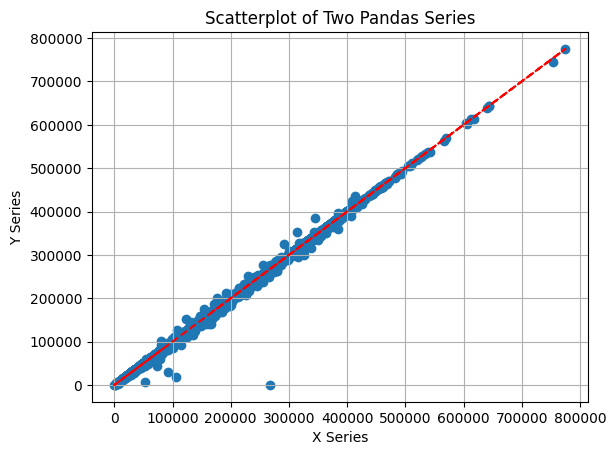

In [13]:
plt.scatter(TRAIN["Current Actual UPB"], TRAIN["Zero Balance Removal UPB"])
plt.plot(TRAIN["Current Actual UPB"], TRAIN["Current Actual UPB"], color='red', linestyle='--', label='y = x')

plt.xlabel("X Series")
plt.ylabel("Y Series")
plt.title("Scatterplot of Two Pandas Series")
plt.grid(True)
plt.show()


In [14]:
TRAIN["UPB Change Until Default"] = TRAIN["Current Actual UPB"] - TRAIN["Zero Balance Removal UPB"]

In [15]:
corr_matrix = TRAIN.corr()


ValueError: could not convert string to float: 'N'

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()
